In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/drive/MyDrive/tweets_clean.csv')
print(df.shape)
df.head(10)

(12679, 10)


,tweet_id,airline_sentiment,negativereason,airline,name,retweet_count,text,tweet_created,user_timezone,text_clean
0,570301083672813571,neutral,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,Central Time (US & Canada),didnt today must mean need take another trip
1,570301031407624196,negative,Bad Flight,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800,Pacific Time (US & Canada),really aggressive blast obnoxious entertainmen...
2,570300817074462722,negative,Can't Tell,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,Pacific Time (US & Canada),really big bad thing
3,570300767074181121,negative,Can't Tell,Virgin America,jnardino,0,@VirginAmerica seriously would pay $30 a fligh...,2015-02-24 11:14:33 -0800,Pacific Time (US & Canada),seriously would pay flight seat didnt playing ...
4,570300616901320704,positive,NaN,Virgin America,cjmcginnis,0,"@VirginAmerica yes, nearly every time I fly VX...",2015-02-24 11:13:57 -0800,Pacific Time (US & Canada),yes nearly every time fly ear worm wont away
5,570295459631263746,positive,NaN,Virgin America,YupitsTate,0,"@VirginAmerica it was amazing, and arrived an ...",2015-02-24 10:53:27 -0800,Eastern Time (US & Canada),amazing arrived hour early youre good
6,570294189143031808,neutral,NaN,Virgin America,idk_but_youtube,0,@VirginAmerica did you know that suicide is th...,2015-02-24 10:48:24 -0800,Eastern Time (US & Canada),know suicide second leading cause death among ...
7,570289724453216256,positive,NaN,Virgin America,HyperCamiLax,0,@VirginAmerica I &lt;3 pretty graphics. so muc...,2015-02-24 10:30:40 -0800,America/New_York,pretty graphic much better minimal iconography
8,570289584061480960,positive,NaN,Virgin America,HyperCamiLax,0,@VirginAmerica This is such a great deal! Alre...,2015-02-24 10:30:06 -0800,America/New_York,great deal already thinking trip amp havent ev...
9,570282469121007616,negative,Late Flight,Virgin America,smartwatermelon,0,@VirginAmerica SFO-PDX schedule is still MIA.,2015-02-24 10:01:50 -0800,Pacific Time (US & Canada),sfopdx schedule still mia


In [4]:
!pip install torch
!pip install shap
!pip install transformers
!pip install scikit-learn

In [5]:
import torch
import shap
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [6]:
df['label'] = df['airline_sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})
print(df['label'].value_counts())

label
0    8575
1    2279
2    1825
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( df['text_clean'],df['label'],test_size=0.2, random_state=42,
                                                    stratify=df['label'])

print(f'Training: {len(X_train)} rows')
print(f'Testing:  {len(X_test)} rows')

Training: 10143 rows
Testing:  2536 rows


In [8]:
tokenizer = AutoTokenizer.from_pretrained('cardiffnlp/twitter-roberta-base-sentiment', num_labels=3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [9]:
def tokenize_data(texts, tokenizer, max_length=128):
    return tokenizer(
        list(texts),
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )

train_encodings = tokenize_data(X_train, tokenizer)
test_encodings  = tokenize_data(X_test, tokenizer)


In [10]:
print(train_encodings['input_ids'].shape)
print(test_encodings['input_ids'].shape)

torch.Size([10143, 38])
torch.Size([2536, 28])


In [11]:
class TweetDataset:
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

train_dataset = TweetDataset(train_encodings, y_train)
test_dataset  = TweetDataset(test_encodings, y_test)

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    'cardiffnlp/twitter-roberta-base-sentiment',
    num_labels=3
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
print(torch.cuda.is_available())

True


In [14]:
from transformers import Trainer, TrainingArguments
import torch
import torch.nn as nn

# Class weights tensor
class_weights = torch.tensor([0.49, 1.85, 2.32]).to('cuda' if torch.cuda.is_available() else 'cpu')

# Custom trainer with weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [15]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

In [16]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.660175,0.652150
2,0.460256,0.582295
3,0.338418,0.808167


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1902, training_loss=0.43312831682110936, metrics={'train_runtime': 344.4577, 'train_samples_per_second': 88.339, 'train_steps_per_second': 5.522, 'total_flos': 594215959268988.0, 'train_loss': 0.43312831682110936, 'epoch': 3.0})

In [18]:
model.save_pretrained('/content/drive/MyDrive/airline_model')
tokenizer.save_pretrained('/content/drive/MyDrive/airline_model')
print('Saved to Drive permanently!')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to Drive permanently!


In [19]:
import os
for folder in sorted(os.listdir('./results')):
    print(folder)


checkpoint-1268
checkpoint-1902
checkpoint-634


In [ ]:
# Load saved best model instead
#model = AutoModelForSequenceClassification.from_pretrained('./results/checkpoint-1268')
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#model = model.to(device)
#print('Model loaded from checkpoint!')

In [ ]:
#import shutil
#shutil.rmtree('./results', ignore_errors=True)
#print('Old checkpoints cleared!')

In [20]:
# Step 1 - get predictions
predictions = trainer.predict(test_dataset)
pred_labels = predictions.predictions.argmax(axis = 1)
# Step 2 - get true labels
true_labels = y_test
# Step 3 - print F1 report
from sklearn.metrics import classification_report
print(classification_report(true_labels, pred_labels,
      target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.91      0.88      0.90      1715
     neutral       0.59      0.69      0.64       456
    positive       0.79      0.76      0.78       365

    accuracy                           0.83      2536
   macro avg       0.76      0.78      0.77      2536
weighted avg       0.84      0.83      0.83      2536



In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
# Step 1 - create prediction function SHAP can use
def predict_proba(texts):
    inputs = tokenizer(list(texts),
                      padding=True,
                      truncation=True,
                      max_length=128,
                      return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    return probs.cpu().numpy()

# Step 2 - take small sample of test tweets
sample_texts = X_test.values[:10]

# Step 3 - create SHAP explainer
explainer = shap.Explainer(predict_proba,
                           shap.maskers.Text(tokenizer))

# Step 4 - calculate SHAP values
shap_values = explainer(sample_texts)
print('SHAP done!')

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [00:15,  5.03s/it]

SHAP done!


In [23]:
# Text plot for first tweet
shap.plots.text(shap_values[0])

In [24]:
print(type(model))
print(type(tokenizer))

<class 'transformers.models.roberta.modeling_roberta.RobertaForSequenceClassification'>
<class 'transformers.models.roberta.tokenization_roberta.RobertaTokenizer'>


Tweet: "finally rectified flight situation thanks"
Model prediction: neutral
Why: "situation" pushed toward negative,
     "finally/thanks" pushed toward positive
     → mixed signals = neutral

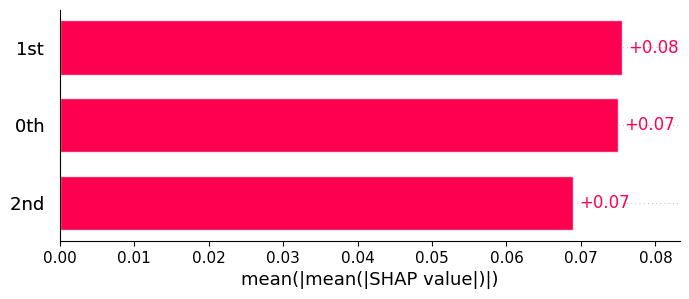

In [26]:
# Bar plot alternative
shap.plots.bar(shap_values.abs.mean(0))

In [27]:
# Save predictions to CSV
df_test = X_test.reset_index(drop=True).to_frame()
df_test['true_label'] = y_test.values
df_test['predicted_label'] = pred_labels
df_test.to_csv('/content/drive/MyDrive/predictions.csv', index=False)
print('Predictions saved!')

Predictions saved!


In [29]:
!pip install bertopic
from bertopic import BERTopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [34]:
neg_df = df[df['airline_sentiment'] == 'negative']
docs = neg_df['text_clean'].tolist()

In [35]:
topic_model = BERTopic(nr_topics='auto')
topics, probs = topic_model.fit_transform(docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [36]:
topic_info = topic_model.get_topic_info()
print(topic_info)

    Topic  Count                                     Name  \
0      -1   3361              -1_flight_not_cancelled_get   
1       0    959               0_bag_luggage_baggage_lost   
2       1    451  1_cancelled_flightled_flighted_customer   
3       2    307             2_gate_agent_sitting_waiting   
4       3    261                3_amp_hold_call_cancelled   
..    ...    ...                                      ...   
85     84     10         84_bumper_supposed_finally_leave   
86     85     10               85_book_blue_jet_pleasegod   
87     86     10     86_dissapointment_heard_nothing_done   
88     87     10          87_voucher_use_expires_headache   
89     88     10                 88_ad_phone_eating_eight   

                                       Representation  \
0   [flight, not, cancelled, get, time, hour, serv...   
1   [bag, luggage, baggage, lost, claim, checked, ...   
2   [cancelled, flightled, flighted, customer, reb...   
3   [gate, agent, sitting, waiting, min

Topic 0: bag, luggage, baggage, lost, claim    → This is about baggage issues
Topic 1: cancelled, rebook, customer    → cancellation + rebooking
Topic 2: gate, agent, sitting, waiting, plane  → This is about waiting issues
Topic 3: hold, call, cancelled, hr, min → cancellation + phone hold

In [37]:
topic_model.visualize_topics()

In [38]:
fig = topic_model.visualize_topics()
fig.show()

In [39]:
# How you saved RoBERTa:
model.save_pretrained('/content/drive/MyDrive/airline_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
topic_model.visualize_barchart(top_n_topics=10)

We analyzed 8,575 negative tweets from 6 major US airlines using BERTopic topic modeling to automatically discover hidden complaint themes. The three biggest issues were baggage handling (959 tweets), flight cancellations and rebooking, and flight delays. Notably, BERTopic uncovered food and catering complaints as a significant theme — a category that never appeared in the original labeled data. Airlines should prioritize baggage handling training for ground staff, as it represents the single largest distinct complaint cluster.


In [41]:
df_bertopic = neg_df[['text_clean', 'airline_sentiment','negativereason', 'airline']].copy()
df_bertopic['topic'] = topics
df_bertopic.to_csv('/content/drive/MyDrive/bertopic_output.csv', index=False)